√ File loaded successfully.

Number of Observations (T): 3773


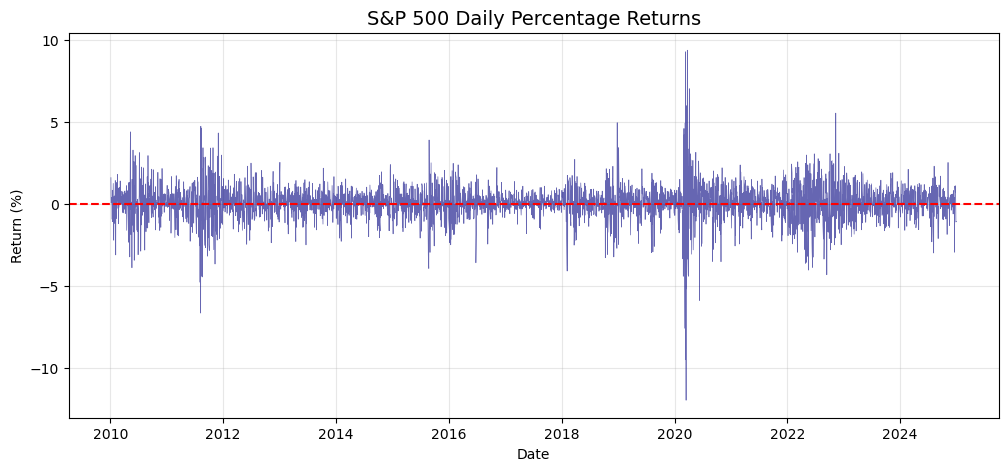

In [7]:
#Phase 1: Data Preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load Data
file_path = 'snp500.csv' 
try:
    df = pd.read_csv(file_path)
    print("√ File loaded successfully.")
except FileNotFoundError:
    print("X Error: File not found.")

#Calculate Returns
adj = df['adjusted'].values
Y = 100 * (adj[1:] / adj[:-1] - 1) # Using equation (P_t / P_t-1 - 1) * 100

#Date Index
dates = pd.to_datetime(df['date'], dayfirst=True)[1:]
T = len(Y)

print(f"\nNumber of Observations (T): {T}")

#Visualization
plt.figure(figsize=(12, 5))
plt.plot(dates, Y, label='Daily Returns (%)', color='navy', alpha=0.6, linewidth=0.5)
plt.title('S&P 500 Daily Percentage Returns', fontsize=14)
plt.ylabel('Return (%)')
plt.xlabel('Date')
plt.axhline(0, color='red', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
#Phase 2: Gibbs Sampler Initialization
K = 3
n_iter = 20000
burn_in = 5000
thin = 5
np.random.seed(78) 

#Hyperparameters
m0 = np.zeros(K)
s0_sq = np.ones(K) * 100.0

a0 = np.ones(K) * 2.0
b0 = np.ones(K) * 1.0

p0 = np.ones(K)

print("Prior distributions set.")

#Initialization
z = np.random.randint(0, K, size=T) # Random label
phi = np.ones(K) / K
mu = np.zeros(K)
sigma_sq = np.ones(K) * np.var(Y) # Initialize with overall variance

#One-step update to refine initial values
for k in range(K):
    idx = (z == k)
    if np.sum(idx) > 0:
        mu[k] = np.mean(Y[idx])
        sigma_sq[k] = np.var(Y[idx])
    else:
        mu[k] = m0[k] + np.random.randn() * np.sqrt(s0_sq[k])
        # Gamma scale = 1/beta
        sigma_sq[k] = 1.0 / np.random.gamma(a0[k], 1.0/b0[k])

print("\n[Initialization Complete]")
for k in range(K):
    print(f"Cluster {k}: Mu={mu[k]:.4f}, Var={sigma_sq[k]:.4f}")

Prior distributions set.

[Initialization Complete]
Cluster 0: Mu=0.0515, Var=1.3081
Cluster 1: Mu=0.0425, Var=1.1405
Cluster 2: Mu=0.0563, Var=1.0797


In [ ]:
#Phase 3: Gibbs Sampler Loop 
import scipy.stats as stats
from itertools import permutations  

#Storage for samples
n_keep = (n_iter - burn_in) // thin
trace_mu = np.zeros((n_keep, K))
trace_sigma_sq = np.zeros((n_keep, K))
trace_phi = np.zeros((n_keep, K))

trace_mu_raw = np.zeros((n_keep, K)) #For comparison
#Initialize Reference Z for sorting
z_ref = None 

print("Starting Gibbs Sampling...")

for i in range(n_iter):
    #Sample States Z (Labeling)
    log_probs = np.zeros((T, K))
    
    #Calculate log-probability log(phi) + log(N(y | mu, sigma)). For efficiency
    for k in range(K):
        log_probs[:, k] = np.log(phi[k] + 1e-100) + \
                          stats.norm.logpdf(Y, loc=mu[k], scale=np.sqrt(sigma_sq[k]))
    
    #Normalize Probabilities using Log-Sum-Exp trick for stability
    max_log = np.max(log_probs, axis=1, keepdims=True)
    probs = np.exp(log_probs - max_log)
    probs /= np.sum(probs, axis=1, keepdims=True)
    
    #Sample new Z for each time point
    cumsum_probs = np.cumsum(probs, axis=1)
    rand_vals = np.random.rand(T, 1)
    z = np.argmax(rand_vals < cumsum_probs, axis=1)
    
    #Count members in each cluster
    nk = np.zeros(K)
    for k in range(K):
        nk[k] = np.sum(z == k)

    #Sample Parameters Mu and Sigma^2
    for k in range(K):
        y_k = Y[z == k]
        n_k = len(y_k)

        if n_k > 0:
            prec_0 = 1.0 / s0_sq[k]
            prec_data = n_k / sigma_sq[k]
            prec_post = prec_0 + prec_data
            var_post = 1.0 / prec_post
            mean_post = var_post * ( (m0[k] / s0_sq[k]) + (np.sum(y_k) / sigma_sq[k]) )
            mu[k] = np.random.normal(mean_post, np.sqrt(var_post))
            a_post = a0[k] + n_k / 2.0
            sse = np.sum((y_k - mu[k])**2)
            b_post = b0[k] + 0.5 * sse
            sigma_sq[k] = 1.0 / np.random.gamma(a_post, 1.0 / b_post)
        else:
            mu[k] = np.random.normal(m0[k], np.sqrt(s0_sq[k]))
            sigma_sq[k] = 1.0 / np.random.gamma(a0[k], 1.0 / b0[k])

    #Sample Weights Phi (Dirichlet)
    phi = np.random.dirichlet(p0 + nk)

    #Random Permutation (To explore modes)
    #Randomly shuffle labels to ensure good mixing
    perm = np.random.permutation(K)
    mu = mu[perm]
    sigma_sq = sigma_sq[perm]
    phi = phi[perm]
    
    #Create a mapping: old_label to new_label
    mapping = np.zeros(K, dtype=int)
    mapping[perm] = np.arange(K)
    z = mapping[z]

    #Save & Sort (Modified: Sort by Z-Alignment)
    if i >= burn_in and (i - burn_in) % thin == 0:
        keep_idx = (i - burn_in) // thin
        trace_mu_raw[keep_idx, :] = mu #Store raw samples for comparison
        if keep_idx == 0:
            z_ref = z.copy()
            order = np.arange(K)
        else:
            match_counts = np.zeros((K, K))
            for k_curr in range(K):
                for k_ref in range(K):
                    match_counts[k_curr, k_ref] = np.sum((z == k_curr) & (z_ref == k_ref))
            
            best_score = -1
            best_perm = None
            
            for p in permutations(range(K)):
                score = 0
                for k_curr, k_target_ref in enumerate(p):
                    score += match_counts[k_curr, k_target_ref]
                
                if score > best_score:
                    best_score = score
                    best_perm = p
            
            # Construct order array to re-arrange parameters
            current_order = np.zeros(K, dtype=int)
            for src_idx, dst_ref_idx in enumerate(best_perm):
                current_order[dst_ref_idx] = src_idx
            
            order = current_order

        #Store ordered samples
        trace_mu[keep_idx, :] = mu[order]
        trace_sigma_sq[keep_idx, :] = sigma_sq[order]
        trace_phi[keep_idx, :] = phi[order]

    if i % 5000 == 0:
        print(f"Iteration {i}/{n_iter}")

print("Gibbs Sampling Completed.")

Starting Gibbs Sampling...
Iteration 0/20000
Iteration 5000/20000
Iteration 10000/20000
Iteration 15000/20000
Gibbs Sampling Completed.


Number of samples for analysis: 3000
Regime Identification:
  Cluster 0 identified as: Recession (Mean Mu: -0.4807)
  Cluster 2 identified as: Stable (Mean Mu: 0.0779)
  Cluster 1 identified as: Growth (Mean Mu: 0.0866)


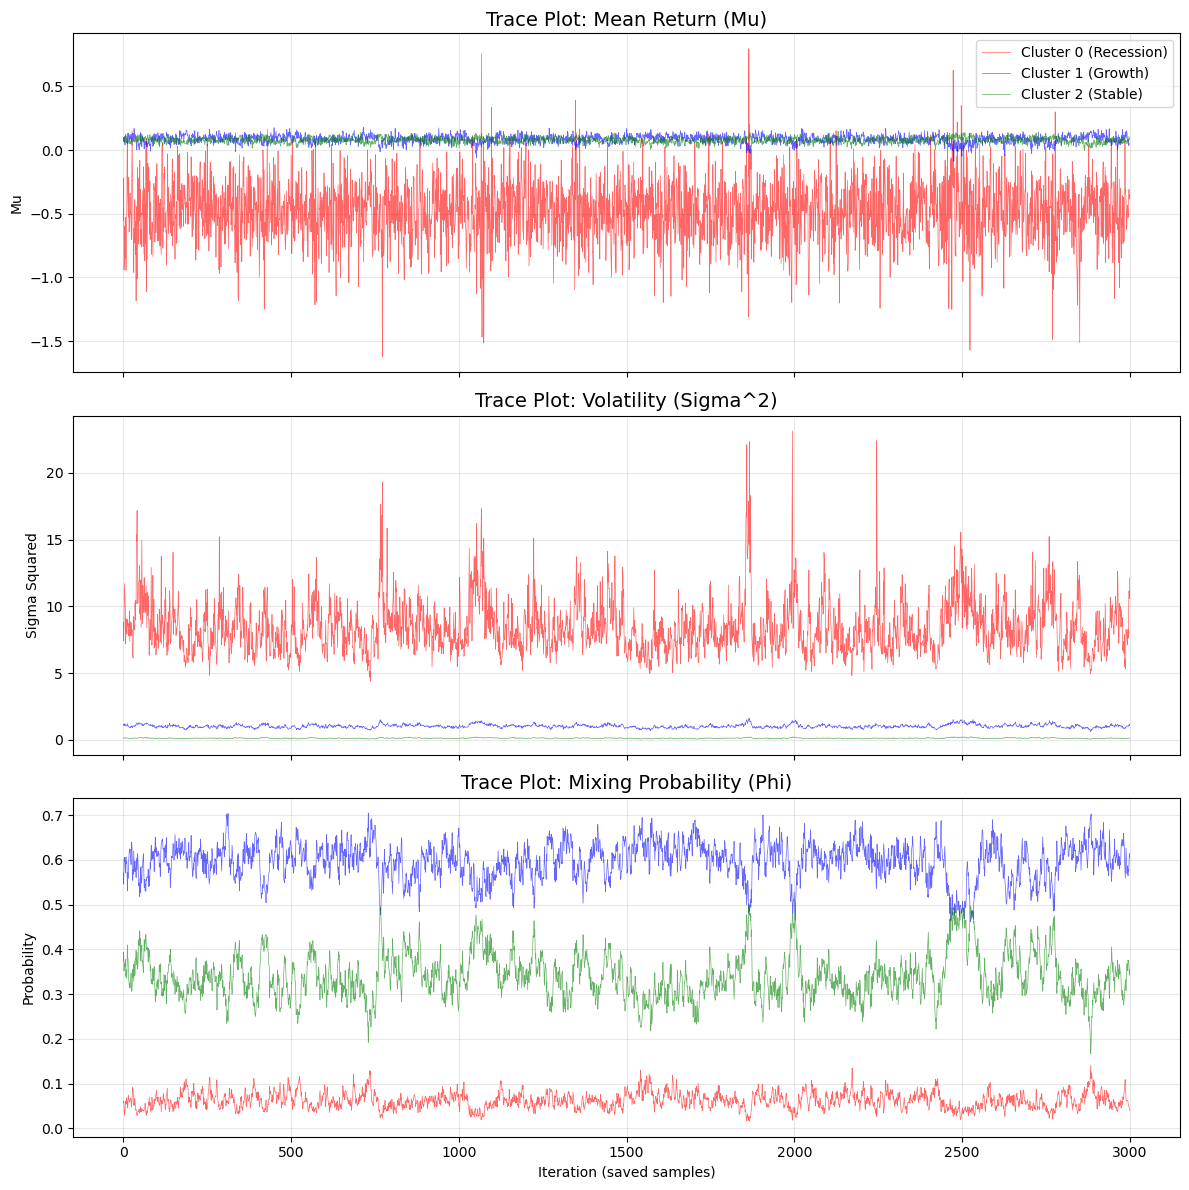

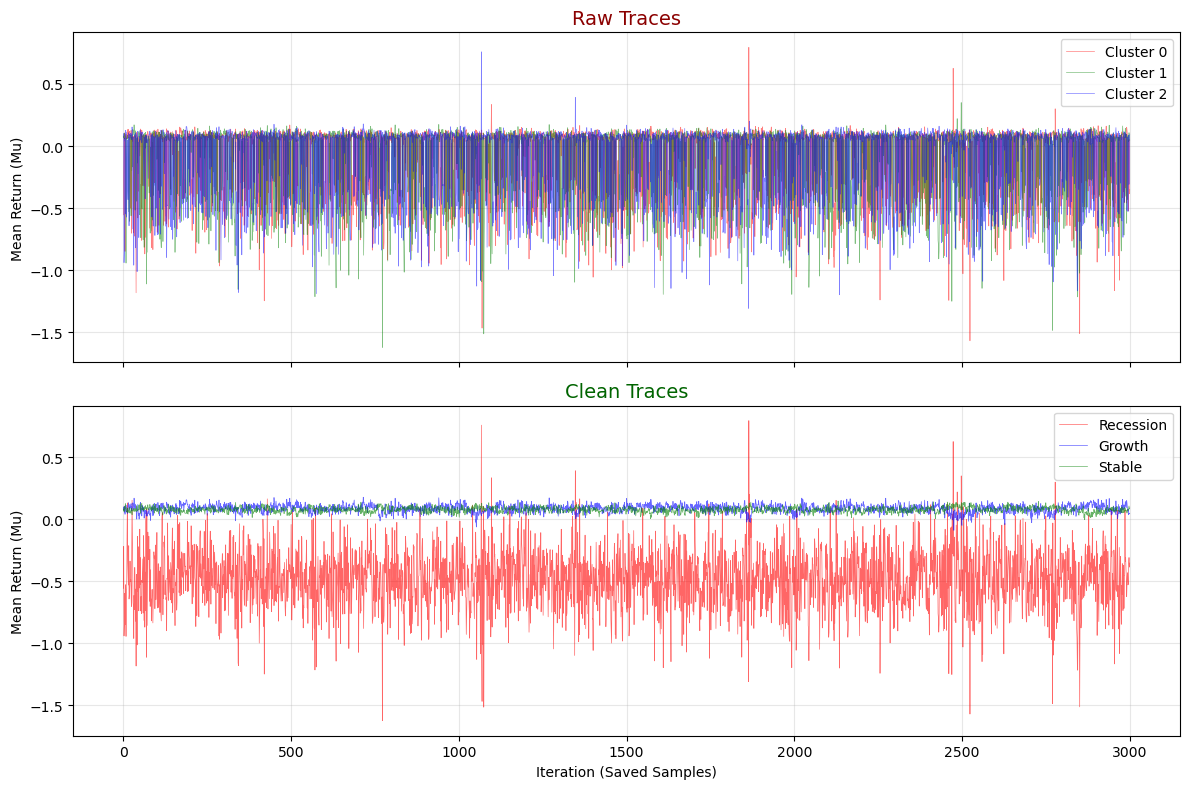

In [10]:
#Phase 4: Analysis & Visualization

#4.1 Visualize Trace
import matplotlib.pyplot as plt

final_mu = trace_mu
final_sigma_sq = trace_sigma_sq
final_phi = trace_phi

#Check number of stored samples
n_samples = final_mu.shape[0]
print(f"Number of samples for analysis: {n_samples}")

#Calculate posterior mean for each cluster to identify regimes
post_mean_mu = np.mean(final_mu, axis=0)

#Sort indices based on Mean Return.
#idx_sorted[0] -> Index of Lowest Mean (Recession)
#idx_sorted[2] -> Index of Highest Mean (Growth)
idx_sorted = np.argsort(post_mean_mu)

#Create a mapping: Cluster Index -> Label & Color
regime_info = {}

#Assign 'Recession' (Red) to the cluster with lowest mean
regime_info[idx_sorted[0]] = {'label': 'Recession', 'color': 'red'}
#Assign 'Stable' (Green) to the cluster with middle mean
regime_info[idx_sorted[1]] = {'label': 'Stable', 'color': 'green'}
#Assign 'Growth' (Blue) to the cluster with highest mean
regime_info[idx_sorted[2]] = {'label': 'Growth', 'color': 'blue'}

print("Regime Identification:")
for k, info in regime_info.items():
    print(f"  Cluster {k} identified as: {info['label']} (Mean Mu: {post_mean_mu[k]:.4f})")

#Generate Trace Plots
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

#(1) Mu Trace
for k in range(K):
    info = regime_info[k]
    axes[0].plot(final_mu[:, k], color=info['color'], alpha=0.6, lw=0.5, 
                 label=f"Cluster {k} ({info['label']})")

axes[0].set_title('Trace Plot: Mean Return (Mu)', fontsize=14)
axes[0].set_ylabel('Mu')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

#(2) Sigma^2 Trace
for k in range(K):
    info = regime_info[k]
    axes[1].plot(final_sigma_sq[:, k], color=info['color'], alpha=0.6, lw=0.5, 
                 label=f"Cluster {k} ({info['label']})")

axes[1].set_title('Trace Plot: Volatility (Sigma^2)', fontsize=14)
axes[1].set_ylabel('Sigma Squared')
axes[1].grid(True, alpha=0.3)

#(3) Phi Trace
for k in range(K):
    info = regime_info[k]
    axes[2].plot(final_phi[:, k], color=info['color'], alpha=0.6, lw=0.5, 
                 label=f"Cluster {k} ({info['label']})")

axes[2].set_title('Trace Plot: Mixing Probability (Phi)', fontsize=14)
axes[2].set_ylabel('Probability')
axes[2].set_xlabel('Iteration (saved samples)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#4.2 Comparison of Raw vs Sorted Traces(Use mean as example)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

#4.2.1 For raw data
axes[0].plot(trace_mu_raw[:, 0], color='red', alpha=0.5, lw=0.5, label='Cluster 0')
axes[0].plot(trace_mu_raw[:, 1], color='green', alpha=0.5, lw=0.5, label='Cluster 1')
axes[0].plot(trace_mu_raw[:, 2], color='blue', alpha=0.5, lw=0.5, label='Cluster 2')
axes[0].set_title('Raw Traces', fontsize=14, color='darkred')
axes[0].set_ylabel('Mean Return (Mu)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

#4.2.2 For sorted data
axes[1].plot(final_mu[:, 0], color=regime_info[0]['color'], alpha=0.6, lw=0.5, label=regime_info[0]['label'])
axes[1].plot(final_mu[:, 1], color=regime_info[1]['color'], alpha=0.6, lw=0.5, label=regime_info[1]['label'])
axes[1].plot(final_mu[:, 2], color=regime_info[2]['color'], alpha=0.6, lw=0.5, label=regime_info[2]['label'])

axes[1].set_title('Clean Traces', fontsize=14, color='darkgreen')
axes[1].set_ylabel('Mean Return (Mu)')
axes[1].set_xlabel('Iteration (Saved Samples)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
#4.3: Summary Statistics & Interpretation
import pandas as pd

#Dynamic Regime Identification
mu_means_all = np.mean(final_mu, axis=0)
idx_sorted = np.argsort(mu_means_all)

recession_idx = idx_sorted[0]
stable_idx = idx_sorted[1]
growth_idx = idx_sorted[2]

regime_map = {
    recession_idx: 'Recession',
    stable_idx:    'Stable',
    growth_idx:    'Growth'
}

print(f"Identified Regimes: Recession=Cluster {recession_idx}, Stable=Cluster {stable_idx}, Growth=Cluster {growth_idx}")

#Generate Statistics Table
summary_data = []

ordered_indices = [recession_idx, stable_idx, growth_idx]
for k in ordered_indices:
    label = regime_map[k]
    
    mu_mean = np.mean(final_mu[:, k])
    sig_mean = np.mean(final_sigma_sq[:, k])
    phi_mean = np.mean(final_phi[:, k])
    
    mu_ci = np.percentile(final_mu[:, k], [2.5, 97.5])
    sig_ci = np.percentile(final_sigma_sq[:, k], [2.5, 97.5])
    phi_ci = np.percentile(final_phi[:, k], [2.5, 97.5])

    summary_data.append({
        'Regime': label,
        'Cluster ID': f"Cluster {k}",
        'Mu (Mean Return)': f"{mu_mean:.4f} [{mu_ci[0]:.3f}, {mu_ci[1]:.3f}]",
        'Sigma^2 (Volatility)': f"{sig_mean:.4f} [{sig_ci[0]:.3f}, {sig_ci[1]:.3f}]",
        'Phi (Proportion)': f"{phi_mean:.4f} [{phi_ci[0]:.3f}, {phi_ci[1]:.3f}]"
    })

    df_summary = pd.DataFrame(summary_data)
df_summary.set_index('Regime', inplace=True)

print("\n=== Posterior Summary Statistics (Sorted by Regime) ===")
print(df_summary)

Identified Regimes: Recession=Cluster 0, Stable=Cluster 2, Growth=Cluster 1

=== Posterior Summary Statistics (Sorted by Regime) ===
          Cluster ID          Mu (Mean Return)    Sigma^2 (Volatility)  \
Regime                                                                   
Recession  Cluster 0  -0.4807 [-0.960, -0.014]  8.4544 [5.735, 12.853]   
Stable     Cluster 2     0.0779 [0.035, 0.120]   0.1331 [0.088, 0.197]   
Growth     Cluster 1     0.0866 [0.018, 0.144]   1.0356 [0.815, 1.340]   

                Phi (Proportion)  
Regime                            
Recession  0.0624 [0.031, 0.102]  
Stable     0.3405 [0.255, 0.461]  
Growth     0.5971 [0.499, 0.667]  


Calculating regime probabilities for each day...
=== Regime Identification for Phase 5 ===
  Cluster 0: Recession (Low Mean)
  Cluster 2: Stable (Medium Mean)
  Cluster 1: Growth (High Mean)


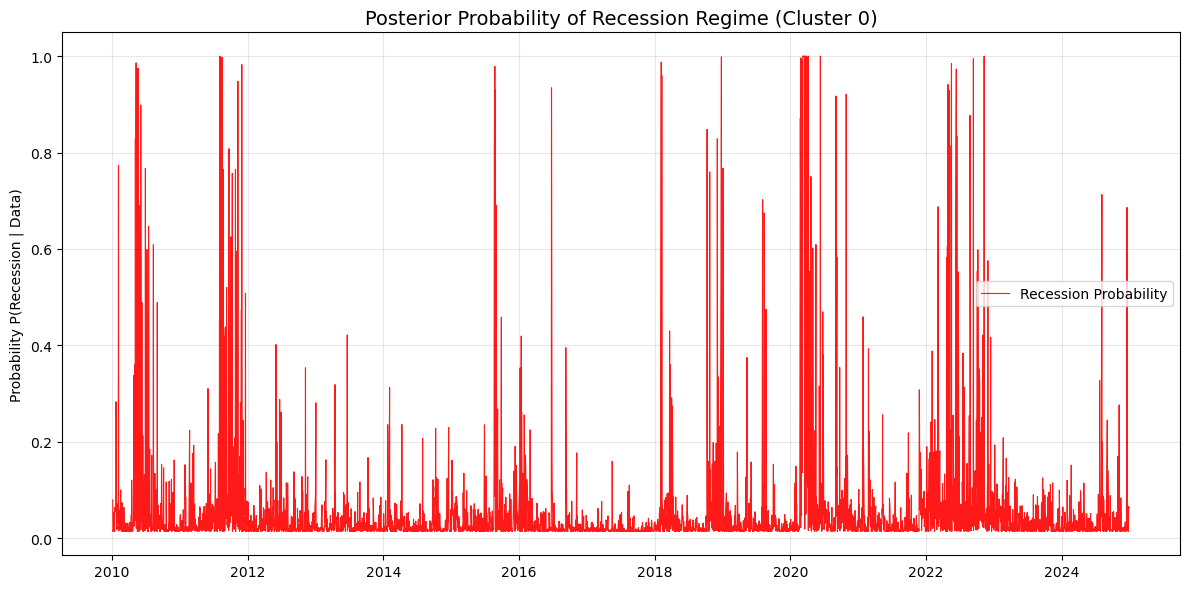

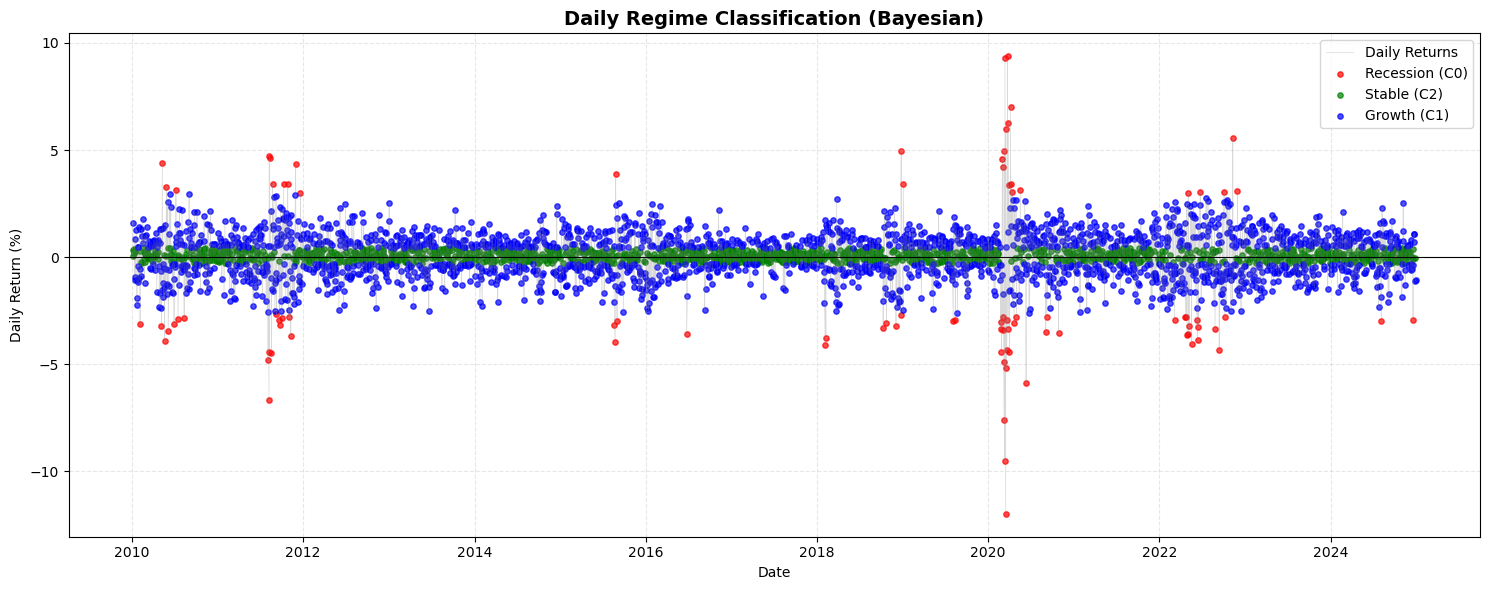

In [12]:
#Task 5: Time Series Analysis

import matplotlib.dates as mdates

print("Calculating regime probabilities for each day...")

#Dynamic Regime Identification
mu_est = np.mean(final_mu, axis=0)
sig_est = np.mean(final_sigma_sq, axis=0)
phi_est = np.mean(final_phi, axis=0)

recession_idx = np.argmin(mu_est)
growth_idx = np.argmax(mu_est)
all_idxs = {0, 1, 2}
stable_idx = list(all_idxs - {recession_idx, growth_idx})[0]

print("=== Regime Identification for Phase 5 ===")
print(f"  Cluster {recession_idx}: Recession (Low Mean)")
print(f"  Cluster {stable_idx}: Stable (Medium Mean)")
print(f"  Cluster {growth_idx}: Growth (High Mean)")

#5.2 Calculate P(z_t = k | y_t) using Point Estimates
regime_probs = np.zeros((T, K))

for t in range(T):
    likelihoods = np.zeros(K)
    for k in range(K):
        # Calculate PDF value
        lik = stats.norm.pdf(Y[t], loc=mu_est[k], scale=np.sqrt(sig_est[k]))
        likelihoods[k] = lik * phi_est[k]
    
    # Normalize
    if np.sum(likelihoods) > 0:
        regime_probs[t, :] = likelihoods / np.sum(likelihoods)
    else:
        regime_probs[t, :] = phi_est 

#5.3 Visualization 1: Probability of Recession
plt.figure(figsize=(12, 6))

plt.plot(dates, regime_probs[:, recession_idx], color='red', linewidth=0.8, alpha=0.9, label='Recession Probability')

plt.title(f'Posterior Probability of Recession Regime (Cluster {recession_idx})', fontsize=14)
plt.ylabel('Probability P(Recession | Data)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#5.4 Full Bayesian Classification (Using all Trace Samples)
#Create space to accumulate probabilities
accumulated_probs = np.zeros((T, K))
n_saved = trace_mu.shape[0]

for i in range(n_saved):
    mu_i = trace_mu[i, :]
    sig_i = trace_sigma_sq[i, :]
    phi_i = trace_phi[i, :]
    
    # Vectorized Probability Calculation
    lik = np.zeros((T, K))
    for k in range(K):
        lik[:, k] = stats.norm.pdf(Y, loc=mu_i[k], scale=np.sqrt(sig_i[k])) * phi_i[k]
    
    row_sums = lik.sum(axis=1)[:, np.newaxis]
    probs_i = lik / (row_sums + 1e-100)
    
    accumulated_probs += probs_i

#Average Probabilities
avg_probs = accumulated_probs / n_saved

#Determine most likely state for each day
most_likely_bayesian = np.argmax(avg_probs, axis=1)

#5.5 Visualization 2: Daily Regime Classification (Scatter Plot)
plt.figure(figsize=(15, 6))

#Plot daily returns background
plt.plot(dates, Y, color='gray', alpha=0.3, linewidth=0.5, label='Daily Returns')

style_map = {
    recession_idx: {'color': 'red', 'label': 'Recession'},
    stable_idx: {'color': 'green', 'label': 'Stable'},
    growth_idx: {'color': 'blue', 'label': 'Growth'}
}

ordered_keys = [recession_idx, stable_idx, growth_idx]

for k in ordered_keys:
    idx = (most_likely_bayesian == k)
    
    style = style_map[k]
    
    if np.sum(idx) > 0:
        plt.scatter(dates[idx], Y[idx], 
                    color=style['color'], 
                    s=15,           
                    alpha=0.7,      
                    label=f"{style['label']} (C{k})")

#Styling
plt.title('Daily Regime Classification (Bayesian)', fontsize=14, fontweight='bold')
plt.ylabel('Daily Return (%)')
plt.xlabel('Date')
plt.legend(loc='upper right', frameon=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')

plt.tight_layout()
plt.show()